# LSST SN Ia Simulation Pipeline

Forward-model SN Ia light curves with the Rubin/LSST 10-year baseline cadence using `lightcurvelynx`.

**Survey**: LSST baseline v5.0.1 OpSim (`baseline_v5.0.1_10yrs.db`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.01–1.2  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

Set `LIGHTCURVELYNX_DATA_DIR` **before** importing lightcurvelynx — the download path is resolved at import time.  
Downloaded files (OpSim DB, passbands) will be stored in `./data/` inside this project directory.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

# Store downloaded data inside this project so it travels with the repo checkout.
# Must be set before any lightcurvelynx imports (path is resolved at import time).
_data_dir = Path().resolve() / "data"
_data_dir.mkdir(exist_ok=True)
os.environ["LIGHTCURVELYNX_DATA_DIR"] = str(_data_dir)
print(f"LIGHTCURVELYNX_DATA_DIR = {_data_dir}")

LIGHTCURVELYNX_DATA_DIR = /Users/mi/Work/lightcurvelynx_sncollab/data


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

## 2. Simulation Configuration

In [4]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SIM_PARAMS = {
    # Cosmology
    "H0": 70.0,
    "Omega_m": 0.315,
    "w": -1.0,
    # Redshift range
    "zmin": 0.001,
    "zmax": 0.7,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.15,
    "beta": 3.15,
    # SALT3 Gaussian priors (no pzflow, no host galaxy)
    "x1_mean": 0.973,  "x1_sigma_minus": 1.472, "x1_sigma_plus": 0.222,
    "c_mean":  -0.054,  "c_sigma_minus":  0.043, "c_sigma_plus":  0.101,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.1,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # LSST WFD footprint in deg²
    "tmin": 60960,
    "tmax": 62786,
}

## 3. Load LSST OpSim

The file is downloaded once and cached locally by `OpSim.from_url()`.

In [5]:
# opsim = OpSim.from_parquet("data/opsim/dd_observations.parquet")
opsim = OpSim.from_db("data/opsim/baseline_v5.0.0_LSST_ELAISS1_5yr.db")
print(f"OpSim loaded: {len(opsim):,} observations")
print(f"MJD range: {opsim['time'].min():.1f} – {opsim['time'].max():.1f}")
print(f"Filters:    {sorted(opsim['filter'].unique())}")

OpSim loaded: 12,934 observations
MJD range: 60990.0 – 62815.3
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [6]:
sky_coverage = opsim.estimate_coverage()    
# sky_coverage = 75
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 12 deg²


## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [7]:
t_min = SIM_PARAMS["tmin"]
t_max = SIM_PARAMS["tmax"]

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
# nsn = 100
print(f"Expected SNe Ia = {nsn:,}")

nsn = int(nsn*0.1)
print(f"Expected SNe Ia (10%) = {nsn:,}")

Survey length = 5.00 years
Solid angle   = 0.0037 sr  (12 deg²)
Expected SNe Ia = 2,830
Expected SNe Ia (10%) = 283


## 5. Load LSST Passbands

In [8]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

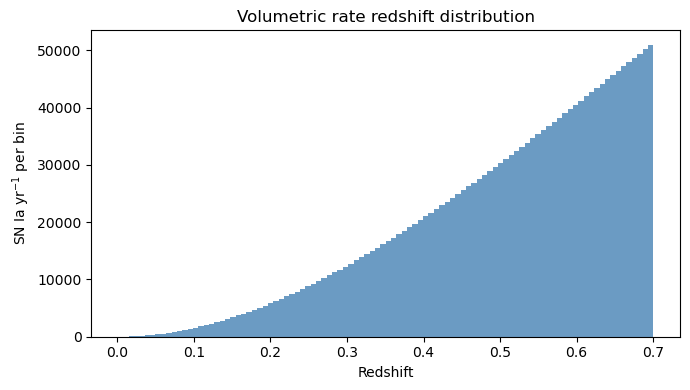

In [9]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ObsTableUniformRADECSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — AsymmetricGaussian($\mu=0.973$, $\sigma_-=1.472$, $\sigma_+=0.222$)
- **c** — AsymmetricGaussian($\mu=-0.054$, $\sigma_-=0.043$, $\sigma_+=0.101$)
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.1$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

In [10]:
# RA/Dec: uniform over the opsim footprint (rejection sampling)
# radec = ObsTableUniformRADECSampler(opsim, node_label="radec")
moc = opsim.build_moc(max_depth=12)
radec = ApproximateMOCSampler(moc, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

# Asymmetric Gaussian SALT3 parameter priors
def asymmetric_gaussian_pdf(x, mu, sigma_minus, sigma_plus):
    norm_factor = np.sqrt(2 / np.pi) / (sigma_minus + sigma_plus)
    return np.where(
        x < mu,
        norm_factor * np.exp(-0.5 * ((x - mu) / sigma_minus) ** 2),
        norm_factor * np.exp(-0.5 * ((x - mu) / sigma_plus) ** 2),
    )
def x1_pdf(x):
    return asymmetric_gaussian_pdf(x, SIM_PARAMS["x1_mean"], SIM_PARAMS["x1_sigma_minus"], SIM_PARAMS["x1_sigma_plus"])
def c_pdf(c):
    return asymmetric_gaussian_pdf(c, SIM_PARAMS["c_mean"], SIM_PARAMS["c_sigma_minus"], SIM_PARAMS["c_sigma_plus"])

x1_func = SamplePDF(x1_pdf, node_label="x1")
c_func = SamplePDF(c_pdf, node_label="c")
m_abs_func = NumpyRandomFunc("normal", loc=SIM_PARAMS["m_abs_mean"], scale=SIM_PARAMS["m_abs_sigma"])

# x0 via Tripp relation
distmod_func = DistModFromRedshift(
    z_func, H0=SIM_PARAMS["H0"], Omega_m=SIM_PARAMS["Omega_m"]
)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=SIM_PARAMS["alpha"],
    beta=SIM_PARAMS["beta"],
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Assemble the SALT3 source (no host galaxy)
source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=radec.ra,
    dec=radec.dec,
    redshift=z_func,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),  
)
print("Source model built successfully.")

Source model built successfully.


## 8. Run Simulation

In [11]:
opsim.columns

Index(['index', 'observationId', 'ra', 'dec', 'time', 'flush_by_mjd',
       'exptime', 'band', 'filter', 'rotation', 'rotSkyPos_desired',
       'nexposure', 'airmass', 'seeingFwhm500', 'seeing', 'seeingFwhmGeom',
       'skybrightness', 'night', 'slewTime', 'visitTime', 'slewDistance',
       'maglim', 'altitude', 'azimuth', 'paraAngle', 'pseudoParaAngle',
       'cloud', 'moonAlt', 'sunAlt', 'scheduler_note', 'target_name',
       'target_id', 'observationStartLST', 'rotTelPos', 'rotTelPos_backup',
       'moonAz', 'sunAz', 'sunRA', 'sunDec', 'moonRA', 'moonDec',
       'moonDistance', 'solarElong', 'moonPhase', 'cummTelAz',
       'observation_reason', 'science_program', 'cloud_extinction', 'zp'],
      dtype='object')

In [12]:
param_cols = [
    "source.t0",
    "source.x0",
    "source.x1",
    "source.c",
    "source.redshift",
    "source.ra",
    "source.dec",
    "x0_func.distmod",
]
obstable_save_cols = ["zp"]

parallel_executor = "loky"  # Options: "loky", "dask", None
if parallel_executor == "loky":
    try:
        import loky
        executor = loky.get_reusable_executor(max_workers=4)
        results = simulate_lightcurves(
            model=source,
            num_samples=nsn,
            obstable=opsim,
            passbands=passbands,
            param_cols=param_cols,
            obstable_save_cols=obstable_save_cols,
            rng=RNG,
            num_jobs=4,
            batch_size=2000,
            executor=executor,
        )
    except ImportError:
        print("Loky is not installed")
elif parallel_executor == "dask":
    try:
        import dask.distributed

        with dask.distributed.Client() as client:
            print(f"Dask dashboard link: {client.dashboard_link}")
            results = simulate_lightcurves(
                model=source,
                num_samples=nsn,
                obstable=opsim,
                passbands=passbands,
                param_cols=param_cols,
                obstable_save_cols=obstable_save_cols,
                rng=RNG,
                num_jobs=4,
                batch_size=2000,
                executor=client,
            )
    except ImportError:
        print("Dask is not installed")
else:
    executor = None
    results = simulate_lightcurves(
        model=source,
        num_samples=nsn,
        obstable=opsim,
        passbands=passbands,
        param_cols=param_cols,
        obstable_save_cols=obstable_save_cols,
        rng=RNG,
        num_jobs=4,
        batch_size=2000,
        executor=executor,
    )
print(f"Generated {len(results)} light curves")
print(results["lightcurve"][0])

print(f"Simulated {len(results):,} SNe Ia")
results.head()

Simulating: 100%|██████████| 71/71 [00:06<00:00, 10.84obj/s]


Generated 283 light curves
                mjd filter         flux     fluxerr  flux_perfect  survey_idx  \
0      60990.033239      y   795.146924  642.156675      0.000000           0   
1      60990.033633      y   339.435726  640.515035      0.000000           0   
...             ...    ...          ...         ...           ...         ...   
12932  62815.304395      i -1151.580835  590.292706    128.864456           0   
12933  62815.304789      i   865.633524  598.864565    128.863811           0   

       obs_idx  is_saturated        zp  
0            0         False  2.280864  
1            1         False  2.280328  
...        ...           ...       ...  
12932    12932         False  0.702845  
12933    12933         False  0.704819  

[12934 rows x 9 columns]
Simulated 283 SNe Ia


id         ra        dec   nobs            t0         z  \
0   0  10.553277 -43.624349  12934  62609.864106  0.450488   
1   1  11.748276 -43.124316    621  61549.378529  0.584608   
2   2   8.655199 -42.231571   1515  62010.995187  0.489952   
3   3   8.536199 -42.929608  12934  61867.793442  0.433516   
4   4   8.352312 -43.629076  12934  61095.703161  0.485860   

                                              params     source_t0  source_x0  \
0  {'radec.ra': 10.553276548561128, 'radec.dec': ...  62609.864106   0.000021   
1  {'radec.ra': 11.748276409730645, 'radec.dec': ...  61549.378529   0.000010   
2  {'radec.ra': 8.655199169602108, 'radec.dec': -...  62010.995187   0.000014   
3  {'radec.ra': 8.53619888641253, 'radec.dec': -4...  61867.793442   0.000011   
4  {'radec.ra': 8.352312228576771, 'radec.dec': -...  61095.703161   0.000010   

   source_x1  source_c  source_redshift  source_ra  source_dec  \
0   0.895594 -0.094442         0.450488  10.553277  -43.624349   
1  -1.352006 -0.102469         0.584608  11.748276  -43.124316   
2  -0.421993 -0.050145         0.489952   8.655199  -42.231571   
3  -2.491730  0.029025         0.433516   8.536199  -42.929608   
4   0.986356  0.145431         0.485860   8.352312  -43.629076   

   x0_func_distmod                                         lightcurve  
0        41.980279  [{mjd: 60990.033239, filter: 'y', flux: 795.14...  
1        42.657775  [{mjd: 61032.059159, filter: 'z', flux: -25.39...  
2        42.197328  [{mjd: 61002.087705, filter: 'r', flux: 145.82...  
3        41.881444  [{mjd: 60990.033239, filter: 'y', flux: -1051....  
4        42.175593  [{mjd: 60990.033239, filter: 'y', flux: -666.6...

## 9. Diagnostics

Quick sanity checks on the simulated population.

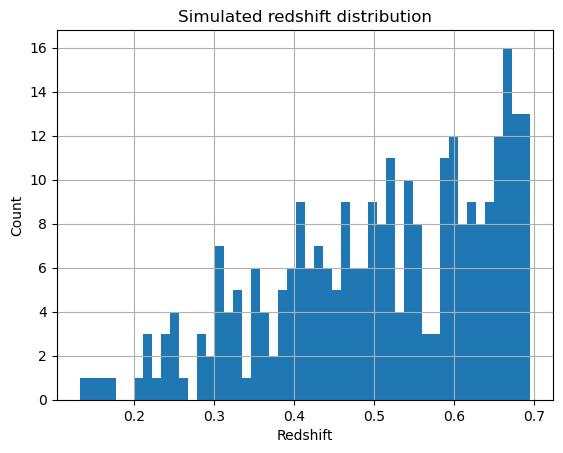

In [13]:
# redshift distribution of simulated SNe
fig, ax = plt.subplots()
results["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution")
plt.show()

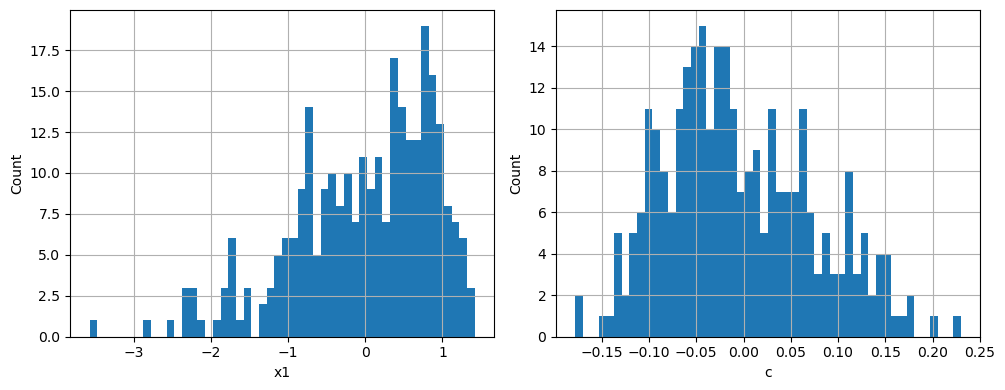

In [14]:
# x1 and c distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
results["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

                mjd filter        flux     fluxerr  flux_perfect  survey_idx  \
0      60990.033239      y  124.391106  642.156675      0.000000           0   
1      60990.033633      y -629.110012  640.515035      0.000000           0   
...             ...    ...         ...         ...           ...         ...   
12932  62815.304395      i -334.271571  590.219530      5.957363           0   
12933  62815.304789      i  -44.212854  598.792234      5.957363           0   

       obs_idx  is_saturated        zp  
0            0         False  2.280864  
1            1         False  2.280328  
...        ...           ...       ...  
12932    12932         False  0.702845  
12933    12933         False  0.704819  

[12934 rows x 9 columns]


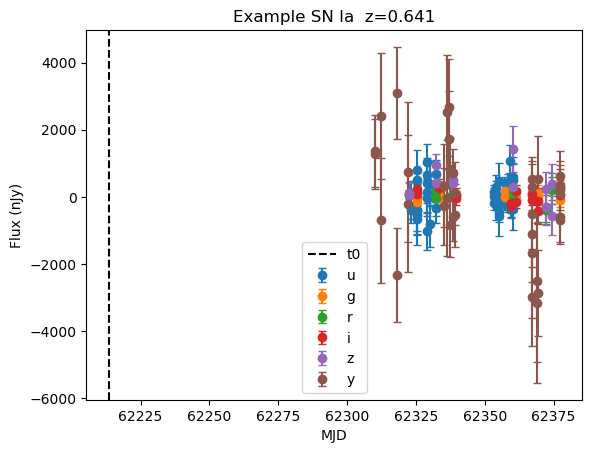

In [15]:
# example light curve for a single SN
sn = results.iloc[np.random.choice(len(results))]
lc = sn["lightcurve"]
print(lc)
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

## 10. Save Results

In [16]:
# save results
output_path = "output/lsst_snia_results.parquet"
output_path = Path(output_path)
output_path.parent.mkdir(exist_ok=True)
results.to_parquet(output_path)
print(f"Saved to {output_path}")

Saved to output/lsst_snia_results.parquet
